# Hospital Cleaning Notebook
This notebook implements the requested cleaning pipeline and saves `hospital_cleaned.csv`.
Each code cell includes comments describing its purpose.

In [55]:
# Imports (seaborn optional)
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display # pyright: ignore[reportMissingModuleSource]
plt.rcParams['figure.figsize'] = (10,6)
try:
    import seaborn as sns
    print('seaborn', sns.__version__)
except Exception:
    sns = None
    print('seaborn not available; falling back to matplotlib for some plots')
print('pandas', pd.__version__)

seaborn 0.13.2
pandas 3.0.3


In [56]:
# 1-2) Load dataset and report shape/columns/info
in_path = 'hospital_raw_data.csv'
p = Path(in_path)
if not p.exists():
    raise FileNotFoundError(f'Input file not found: {in_path}')
df = pd.read_csv(in_path, low_memory=False)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())
print()
df.info()

Shape: (10000, 63)
Columns: ['Hospital ID', 'Hospital Name', 'Hosp+C1:BB1ital Type', 'City', 'State', 'Department', 'Department ID', 'Doctor', 'Nurses', 'Staff Count', 'Patient ID', 'Patient Name', 'Gender', 'Age', 'Admission Date', 'Discharge Date', 'Diagnosis', 'Treatment', 'Medication', 'Admission Type', 'Test Result', 'Blood Type', 'Beds Available', 'ICU Beds', 'Bed Number', 'Bed Occupied', 'Equipment', 'Length of Stay', 'Room No', 'Billing Amount', 'Insurance Provider', 'Re-admission', 'Dept_Bed_Capacity_Derived', 'Beds_Occupied_Count', 'Equipment ID', 'Equipment Number', 'Equipment Status', 'Equipment_Total_Inventory', 'Equipment_Usage_Duration_Hours', 'Transferred', 'Transfer_From_Department', 'Transfer_To_Department', 'Transfer_Date', 'Number_of_Transfers', 'Dept_ICU_Bed_Capacity_Derived', 'Dept_Staff_Capacity_Derived', 'Admissions_Rate_%_Derived', 'Staff_Utilization_%_Derived', 'Bed_Occupancy_Rate_%', 'Admission_Day_Of_Week', 'Admission_Month', 'Admission_Quarter', 'Is_Weekend

,Hospital ID,Hospital Name,Hosp+C1:BB1ital Type,City,State,Department,Department ID,Doctor,Nurses,Staff Count,...,Discharge_Day_Of_Week,Discharge_Month,Age_Group,LOS_Category,High_Risk_Patient,Overstay_Flag,High_Bill_Flag,Admission_Time,Discharge_Time,Unnamed: 62
0,HOSP00016,C K Hospital,Private,Mumbai,Maharashtra,General Medicine,DEPT004,Dr. Arjun Sharma,12,257,...,Friday,February,Child,Long Stay,No,Yes,Yes,2:08,11:02,NaN
1,HOSP00019,Cure Well Hospital,Private,Bengaluru,Karnataka,General Surgery,DEPT010,Dr. Sneha Rao,15,288,...,Wednesday,May,Child,Short Stay,No,No,Yes,18:34,10:43,NaN
2,HOSP00004,Yashoda Hospital,Private,Hyderabad,Telangana,Pulmonology,DEPT005,Dr. Priya Reddy,20,181,...,Monday,May,Adult,Short Stay,No,No,Yes,15:42,13:12,NaN
3,HOSP00017,Dharma Hospital,Private,Delhi,Delhi,Pulmonology,DEPT005,Dr. Rahul Verma,23,170,...,Wednesday,September,Adult,Medium Stay,No,No,No,10:31,14:42,NaN
4,HOSP00017,Dharma Hospital,Private,Delhi,Delhi,ICU,DEPT009,Dr. Priya Reddy,34,116,...,Thursday,December,Adult,Short Stay,No,No,No,10:23,10:33,NaN



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Hospital ID                     10000 non-null  str    
 1   Hospital Name                   10000 non-null  str    
 2   Hosp+C1:BB1ital Type            10000 non-null  str    
 3   City                            10000 non-null  str    
 4   State                           10000 non-null  str    
 5   Department                      10000 non-null  str    
 6   Department ID                   10000 non-null  str    
 7   Doctor                          10000 non-null  str    
 8   Nurses                          10000 non-null  int64  
 9   Staff Count                     10000 non-null  int64  
 10  Patient ID                      10000 non-null  str    
 11  Patient Name                    10000 non-null  str    
 12  Gender                          10000 non-n

In [57]:
# 3) Remove duplicate rows
before = len(df)
df = df.drop_duplicates(keep='first')
after = len(df)
print(f'Removed {before-after} duplicate rows; new shape: {df.shape}')

Removed 0 duplicate rows; new shape: (10000, 63)


In [58]:
# 4) Handle missing patient data
# Capture missing pattern before any imputation for debugging/visualization
missing_before = df.isna().copy()
# 4.a Drop columns with >50% missing
drop_thresh = 0.5
missing_frac = df.isna().mean()
cols_to_drop = missing_frac[missing_frac > drop_thresh].index.tolist()
print('Dropping columns with >50% missing:', cols_to_drop)
df = df.drop(columns=cols_to_drop)
# 4.b Fill numeric columns with median, categorical with mode
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print('Numeric cols:', num_cols)
print('Categorical sample:', cat_cols[:10])
for c in num_cols:
    med = df[c].median(skipna=True)
    df[c] = df[c].fillna(med)
for c in cat_cols:
    try:
        m = df[c].mode(dropna=True)[0]
        df[c] = df[c].fillna(m)
    except Exception:
        df[c] = df[c].fillna('Unknown')
print('Missing after fills (per column):')
print(df.isna().mean().sort_values(ascending=False).head(10))

Dropping columns with >50% missing: ['Transfer_To_Department', 'Transfer_Date', 'Unnamed: 62']
Numeric cols: ['Nurses', 'Staff Count', 'Age', 'Beds Available', 'ICU Beds', 'Bed Number', 'Length of Stay', 'Room No', 'Billing Amount', 'Dept_Bed_Capacity_Derived', 'Beds_Occupied_Count', 'Equipment_Total_Inventory', 'Equipment_Usage_Duration_Hours', 'Number_of_Transfers', 'Dept_ICU_Bed_Capacity_Derived', 'Dept_Staff_Capacity_Derived', 'Admissions_Rate_%_Derived', 'Staff_Utilization_%_Derived', 'Bed_Occupancy_Rate_%']
Categorical sample: ['Hospital ID', 'Hospital Name', 'Hosp+C1:BB1ital Type', 'City', 'State', 'Department', 'Department ID', 'Doctor', 'Patient ID', 'Patient Name']
Missing after fills (per column):
Hospital ID             0.0
Hospital Name           0.0
Hosp+C1:BB1ital Type    0.0
City                    0.0
State                   0.0
Department              0.0
Department ID           0.0
Doctor                  0.0
Nurses                  0.0
Staff Count             0.0
dt

C:\Users\Chenn\AppData\Local\Temp\ipykernel_25276\2515235987.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()


In [59]:
# 5) Standardize department names
dept_map = {
    'Cardio': 'Cardiology',
    'Cardiology Dept': 'Cardiology',
    'Neuro': 'Neurology',
    'Ortho': 'Orthopedics',
    'ENT': 'ENT',
    'ER': 'Emergency',
    'Emergency': 'Emergency'
}
if 'Department' in df.columns:
    df['Department'] = df['Department'].astype(str).str.strip().replace(dept_map).replace({'nan': np.nan})
    df['Department'] = df['Department'].where(df['Department'].isna(), df['Department'].str.title())
    print('Department value counts (top):')
    print(df['Department'].value_counts().head(10))
else:
    print('No Department column found')

Department value counts (top):
Department
Neurology           1033
Oncology            1031
General Surgery     1020
Psychiatry          1016
Icu                 1010
Nephrology           999
Cardiology           991
Pulmonology          978
General Medicine     964
Orthopedics          958
Name: count, dtype: int64


In [60]:
# 6) Normalize healthcare indicators (min-max to 0-1)
indicators = [c for c in ['BloodPressure','HeartRate','Cholesterol'] if c in df.columns]
print('Indicators to normalize:', indicators)
for c in indicators:
    # coerce to numeric (handles strings like '120/80' poorly - best-effort)
    df[c] = pd.to_numeric(df[c], errors='coerce')
    lo = df[c].min(skipna=True)
    hi = df[c].max(skipna=True)
    if pd.isna(lo) or pd.isna(hi) or hi==lo:
        df[c + '_norm'] = 0.0
    else:
        df[c + '_norm'] = (df[c] - lo) / (hi - lo)
display(df[[c + '_norm' for c in indicators]].head())

Indicators to normalize: []


""
0
1
2
3
4


In [61]:
# 7) Convert date columns to datetime
date_cols = [c for c in df.columns if 'date' in c.lower() or c.lower().endswith('date')]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')
print('Parsed date columns:', date_cols)

Parsed date columns: ['Admission Date', 'Discharge Date']


In [62]:
# 8) Ensure overall missing < 2%
total = df.shape[0] * df.shape[1]
missing = df.isna().sum().sum()
pct = missing / total
print(f'Overall missing before final fills: {pct:.2%}')
if pct > 0.02:
    # attempt additional fills
    for c in df.select_dtypes(include=[np.number]).columns:
        df[c] = df[c].fillna(df[c].median())
    for c in df.select_dtypes(include=['object','category']).columns:
        try:
            df[c] = df[c].fillna(df[c].mode(dropna=True)[0])
        except Exception:
            df[c] = df[c].fillna('Unknown')
    missing = df.isna().sum().sum()
    pct = missing / (df.shape[0] * df.shape[1])
    print(f'Overall missing after fills: {pct:.2%}')
    if pct > 0.02:
        # drop rows with any remaining missing values if they are a small fraction
        rows_before = len(df)
        df = df.dropna()
        rows_after = len(df)
        print(f'Dropped {rows_before-rows_after} rows; new shape {df.shape}')
        missing = df.isna().sum().sum()
        pct = missing / (df.shape[0] * df.shape[1])
        print(f'Final missing after drops: {pct:.2%}')
if pct > 0.02:
    print('Warning: dataset still has >2% missing values')

Overall missing before final fills: 0.00%


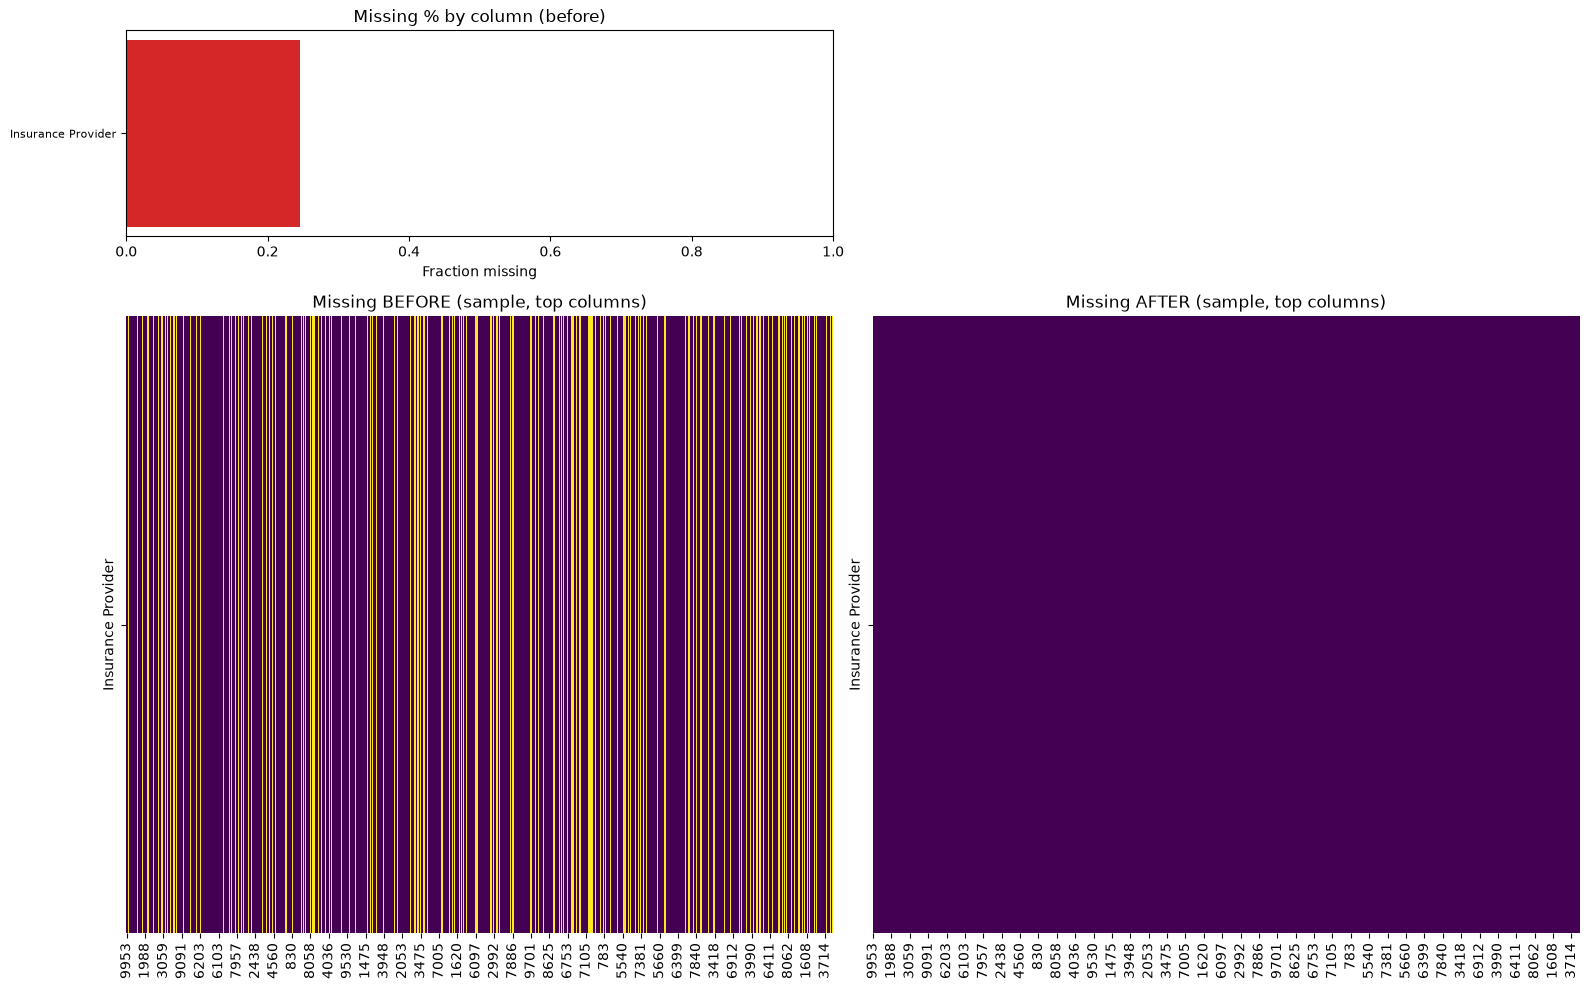

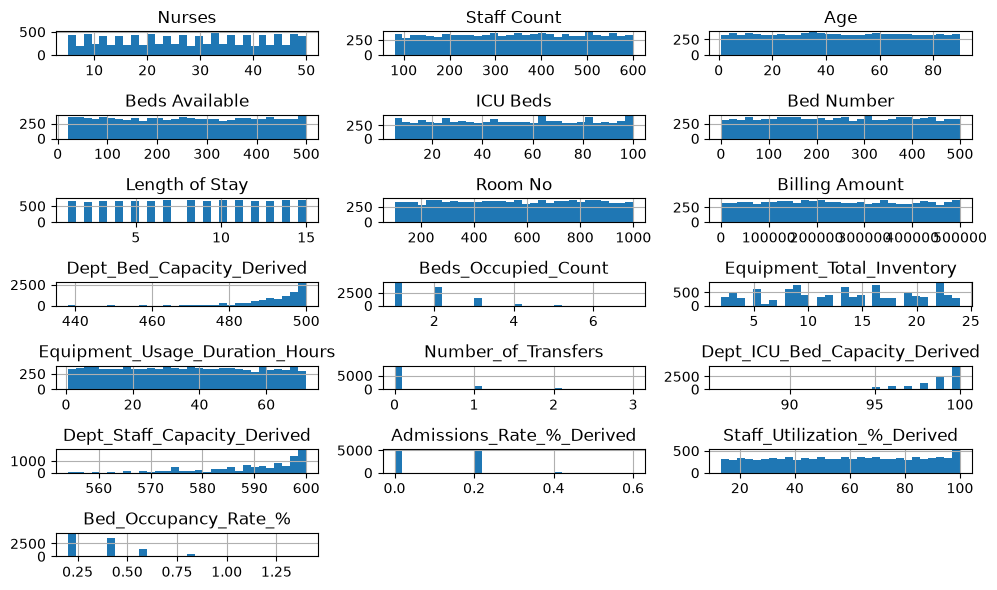

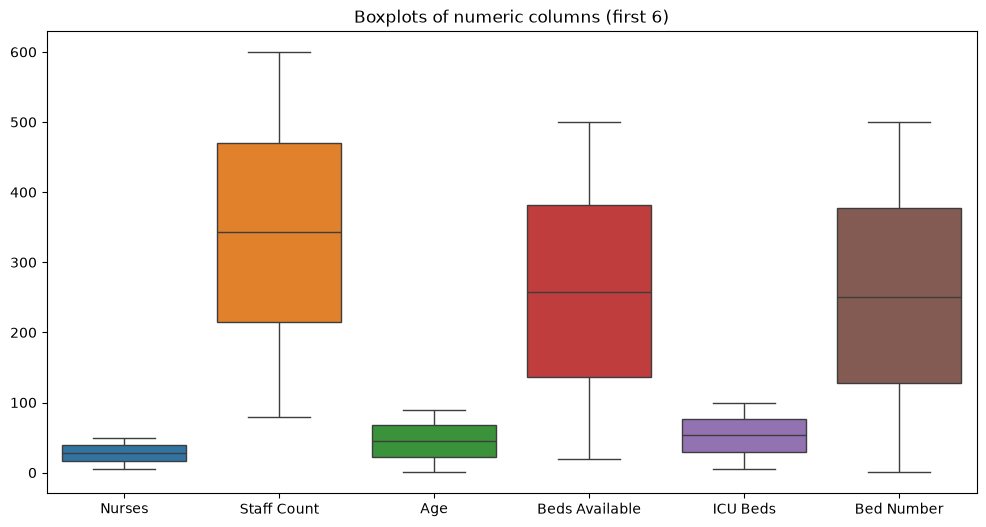

In [63]:
# 9) Visualizations: improved missing-value diagnostics, histograms, boxplots
sample_n = min(1000, len(df))
# If we captured missing_before, focus on top columns with missing data to make heatmaps readable
if 'missing_before' in globals():
    mb = missing_before
    # column-wise missing percent before
    miss_pct = mb.mean().sort_values(ascending=False)
    top_cols = miss_pct[miss_pct>0].index.tolist()[:30] if (miss_pct>0).any() else miss_pct.index[:30]
    # intersect with columns that still exist in df (we may have dropped some columns earlier)
    top_cols = [c for c in top_cols if c in df.columns]
    if len(top_cols)==0:
        print('Top missing columns were dropped earlier; selecting current top-missing columns from df instead')
        cur_miss = df.isna().mean().sort_values(ascending=False)
        top_cols = cur_miss[cur_miss>0].index.tolist()[:30] if (cur_miss>0).any() else cur_miss.index[:30]
    if len(top_cols)==0:
        print('No missing values present (before or after) to visualize')
    else:
        sample_idx = mb.sample(n=sample_n, random_state=1).index.tolist() if len(mb)>sample_n else mb.index.tolist()
        # ensure sample_idx are valid for df (they should be same index unless rows were dropped)
        sample_idx = [i for i in sample_idx if i in df.index]
        sb = mb.loc[sample_idx, top_cols].astype(int)  # before (0/1)
        sa = df.loc[sample_idx, top_cols].isna().astype(int)  # after (0/1)
        fig, axes = plt.subplots(2,2, figsize=(16,10), gridspec_kw={'height_ratios':[1,3]})
        # top-left: bar chart of missing % before (limited to top_cols)
        before_pct = mb[top_cols].mean().loc[top_cols]
        axes[0,0].barh(top_cols[::-1], before_pct.values[::-1], color='C3')
        axes[0,0].set_title('Missing % by column (before)')
        axes[0,0].set_xlim(0,1)
        axes[0,0].set_xlabel('Fraction missing')
        axes[0,0].tick_params(axis='y', labelsize=8)
        axes[0,1].axis('off')
        # bottom: heatmaps before and after (transpose so columns are rows)
        if sns is not None:
            sns.heatmap(sb.T, cbar=False, ax=axes[1,0], cmap='viridis', vmin=0, vmax=1)
            sns.heatmap(sa.T, cbar=False, ax=axes[1,1], cmap='viridis', vmin=0, vmax=1)
        else:
            axes[1,0].imshow(sb.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
            axes[1,1].imshow(sa.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
            axes[1,0].set_yticks(range(len(top_cols)))
            axes[1,0].set_yticklabels(top_cols, fontsize=8)
        axes[1,0].set_title('Missing BEFORE (sample, top columns)')
        axes[1,1].set_title('Missing AFTER (sample, top columns)')
        plt.tight_layout()
        fig.savefig('missing_before_after.png', dpi=150)
        plt.show()
else:
    # fallback: simple heatmap of missing values (sample)
    sample = df.isna().sample(n=sample_n, random_state=1) if len(df)>sample_n else df.isna()
    if sns is not None:
        sns.heatmap(sample, cbar=False, yticklabels=False)
    else:
        plt.imshow(sample.T, aspect='auto', cmap='Greys')
        plt.yticks([])
    plt.title('Missing values heatmap (sample)')
    plt.show()
# Histograms and boxplots for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    df[num_cols].hist(bins=30, layout=(max(1,(len(num_cols)+2)//3),3))
    plt.tight_layout()
    plt.show()
    cols = num_cols[:6]
    plt.figure(figsize=(12,6))
    if sns is not None:
        sns.boxplot(data=df[cols], orient='v')
    else:
        df[cols].boxplot()
    plt.title('Boxplots of numeric columns (first 6)')
    plt.show()

In [64]:
# 10) Save cleaned dataset
out_path = 'hospital_cleaned.csv'
df.to_csv(out_path, index=False)
print(f'Saved cleaned dataset to {out_path}')

Saved cleaned dataset to hospital_cleaned.csv
